# 04 - Análise Final

## Contexto

Este notebook responde as 8 perguntas de negócio do objetivo do projeto, usando o Esquema Estrela da camada Gold (`fact_game`, `dim_game`, `dim_genre`, `bridge_game_genre`). Para cada pergunta: a consulta técnica, uma visualização e a discussão do resultado no contexto do problema.

Duas ressalvas que valem para todas as perguntas abaixo, herdadas da camada Silver: `acceptance_ratio` fica nulo para os jogos sem review em nenhuma das duas APIs (11,6% dos registros da Bronze; com o fallback entre Steam API e SteamSpy, a cobertura é de 88,4%) e `metacritic_score` só está disponível para ~4% dos jogos — perguntas que dependem dessas colunas naturalmente têm menos jogos na base de cálculo.

In [0]:
# Carrega as quatro tabelas Gold usadas nas análises.
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

fact_game = spark.table("gold.steam_games.fact_game")
dim_game = spark.table("gold.steam_games.dim_game")
dim_genre = spark.table("gold.steam_games.dim_genre")
bridge_game_genre = spark.table("gold.steam_games.bridge_game_genre")

In [0]:
# Funções auxiliares: bucketize cria, para uma coluna numérica, um rótulo de faixa (ex.: "5-10") e uma coluna de
# ordem para ordenar as faixas corretamente; bar_chart desenha um gráfico de barras a partir de um DataFrame
# pandas.
def bucketize(column, buckets):
    """buckets: lista de (rotulo, função de condição). Retorna (coluna_rotulo, coluna_ordem)."""
    label_expr, order_expr = None, None
    for i, (label, cond) in enumerate(buckets):
        c = cond(column)
        if label_expr is None:
            label_expr = F.when(c, F.lit(label))
            order_expr = F.when(c, F.lit(i))
        else:
            label_expr = label_expr.when(c, F.lit(label))
            order_expr = order_expr.when(c, F.lit(i))
    return label_expr, order_expr


def bar_chart(pdf, x, y, title, ylabel, rotation=45):
    plt.figure(figsize=(8, 4))
    plt.bar(pdf[x].astype(str), pdf[y])
    plt.xticks(rotation=rotation, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Pergunta 1 — Gênero/categoria influencia a proporção de avaliações positivas?

In [0]:
# Pergunta 1: junta a tabela ponte com dim_genre (por genre_id) e fact_game (por app_id), agrupa por gênero,
# conta os jogos e calcula a média de acceptance_ratio. Mantém só gêneros com pelo menos 500 jogos e ordena do
# maior para o menor.
q1 = (
    bridge_game_genre
    .join(dim_genre, "genre_id")
    .join(fact_game, "app_id")
    .groupBy("genre_name")
    .agg(F.count("*").alias("n_jogos"), F.avg("acceptance_ratio").alias("acceptance_medio"))
    .filter("n_jogos >= 500")
    .orderBy(F.desc("acceptance_medio"))
)
display(q1)

genre_name,n_jogos,acceptance_medio
Free To Play,8872,76.6124582998583
Casual,38719,76.42397720505335
Indie,63226,76.3963049049912
Adventure,35493,75.46973466667816
Action,36890,74.92241992750216
RPG,16349,74.24529741867487
Strategy,17379,73.89916457396897
Racing,3302,73.02877431034896
Early Access,9121,72.68010838720747
Sports,3948,71.68914258444866


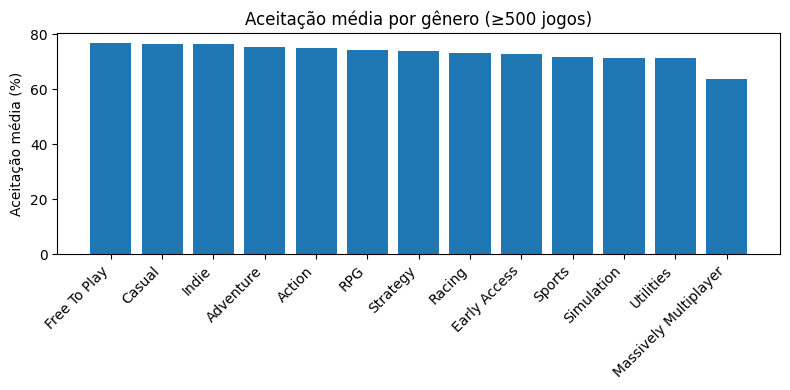

In [0]:
# Gráfico de barras da aceitação média por gênero (resultado da consulta acima convertido para pandas).
bar_chart(q1.toPandas(), "genre_name", "acceptance_medio", "Aceitação média por gênero (≥500 jogos)", "Aceitação média (%)")

**Discussão:** entre os gêneros com pelo menos 500 jogos, a maioria fica concentrada numa faixa estreita (71-77% de aceitação média) — Free To Play, Casual e Indie no topo (~76,5%). O destaque é **Massively Multiplayer**, com aceitação média de **63,7%**, claramente abaixo de todos os outros gêneros. Gênero tem relação com a aceitação, mas o efeito é modesto — exceto para jogos multiplayer massivos, que consistentemente performam pior, provavelmente por serem mais dependentes de infraestrutura de servidor, balanceamento contínuo e suporte pós-lançamento do que os demais gêneros.

## Pergunta 2 — Preço tem relação com a avaliação (mais caro = melhor avaliado)?

In [0]:
# Pergunta 2: divide o preço em faixas (Gratuito, 0-5, 5-10, 10-20, 20-40, 40+) com bucketize, agrupa por faixa
# e calcula a contagem de jogos e a média de acceptance_ratio. Também calcula a correlação entre price e
# acceptance_ratio.
price_buckets = [
    ("Gratuito", lambda c: c == 0),
    ("0-5", lambda c: (c > 0) & (c <= 5)),
    ("5-10", lambda c: (c > 5) & (c <= 10)),
    ("10-20", lambda c: (c > 10) & (c <= 20)),
    ("20-40", lambda c: (c > 20) & (c <= 40)),
    ("40+", lambda c: c > 40),
]
label, order = bucketize(F.col("price"), price_buckets)

q2 = (
    fact_game
    .withColumn("price_bucket", label)
    .withColumn("bucket_order", order)
    .groupBy("price_bucket", "bucket_order")
    .agg(F.count("*").alias("n_jogos"), F.avg("acceptance_ratio").alias("acceptance_medio"))
    .orderBy("bucket_order")
    .drop("bucket_order")
)
display(q2)

correlacao_preco = fact_game.select(F.corr("price", "acceptance_ratio")).collect()[0][0]
print("Correlação price x acceptance_ratio:", round(correlacao_preco, 4))

price_bucket,n_jogos,acceptance_medio
Gratuito,14201,76.52881876171537
0-5,39477,74.1813627539911
5-10,19061,76.52313518596986
10-20,12743,77.3567608533845
20-40,3350,76.22969225956666
40+,897,72.39698976245073


Correlação price x acceptance_ratio: 0.0036


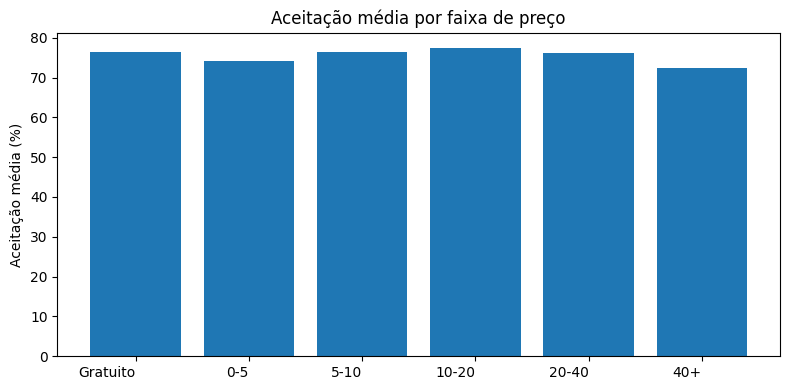

In [0]:
# Gráfico de barras da aceitação média por faixa de preço.
bar_chart(q2.toPandas(), "price_bucket", "acceptance_medio", "Aceitação média por faixa de preço", "Aceitação média (%)", rotation=0)

**Discussão:** a correlação entre preço e aceitação é praticamente nula (**0,004**), e as médias por faixa de preço ficam todas entre 72% e 77%, sem tendência clara de subir com o preço — a faixa mais cara (40+) tem, na verdade, a menor aceitação média (72,4%). **A resposta é não**: preço não é um fator que explica a variação na avaliação dos jogadores nesta base. Isso é relevante para o problema de negócio — sugere que o preço de um jogo é definido por outros critérios (orçamento de produção, gênero, editora) e não funciona como um sinal de qualidade percebida pelos jogadores.

## Pergunta 3 — Desconto ativo está associado a maior popularidade estimada?

In [0]:
# Pergunta 3: separa os jogos entre com desconto (discount > 0) e sem desconto e, para cada grupo, calcula a
# quantidade de jogos e a média de owners estimados e de pico de jogadores simultâneos.
q3 = (
    fact_game
    .withColumn("tem_desconto", F.col("discount") > 0)
    .groupBy("tem_desconto")
    .agg(
        F.count("*").alias("n_jogos"),
        F.avg("estimated_owners_avg").alias("owners_medio"),
        F.avg("peak_ccu").alias("peak_ccu_medio"),
    )
)
display(q3)

tem_desconto,n_jogos,owners_medio,peak_ccu_medio
false,82270,99331.71265345812,97.17381791661602
true,7459,122213.43343611744,110.16087947446039


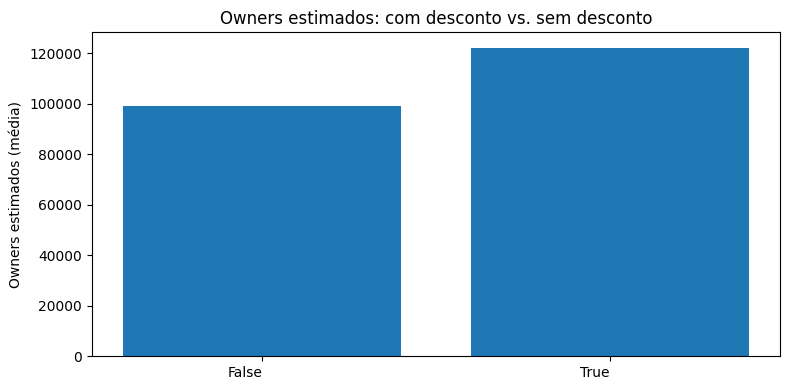

In [0]:
# Gráfico de barras dos owners estimados com e sem desconto.
bar_chart(q3.toPandas(), "tem_desconto", "owners_medio", "Owners estimados: com desconto vs. sem desconto", "Owners estimados (média)", rotation=0)

**Discussão:** jogos com desconto ativo no momento da coleta têm, em média, **22.882** owners estimados a mais que os sem desconto e pico de jogadores simultâneos também maior. Há associação, mas a direção causal não é óbvia: pode ser que descontos aumentem a popularidade, ou o inverso — jogos já populares são os que mais entram em campanhas de desconto (Steam Sales tendem a priorizar títulos de maior visibilidade). Os dados não permitem distinguir as duas hipóteses, só confirmar a associação.

## Pergunta 4 — Suporte multiplataforma está associado a maior popularidade/avaliação?

In [0]:
# Pergunta 4: junta dim_game e fact_game por app_id, agrupa por is_multiplatform e calcula a média de
# acceptance_ratio e de owners estimados.
q4 = (
    dim_game
    .join(fact_game, "app_id")
    .groupBy("is_multiplatform")
    .agg(
        F.count("*").alias("n_jogos"),
        F.avg("acceptance_ratio").alias("acceptance_medio"),
        F.avg("estimated_owners_avg").alias("owners_medio"),
    )
)
display(q4)

is_multiplatform,n_jogos,acceptance_medio,owners_medio
true,20694,79.65313311764949,170715.18314487292
false,69035,74.30138659849297,80406.02592887665


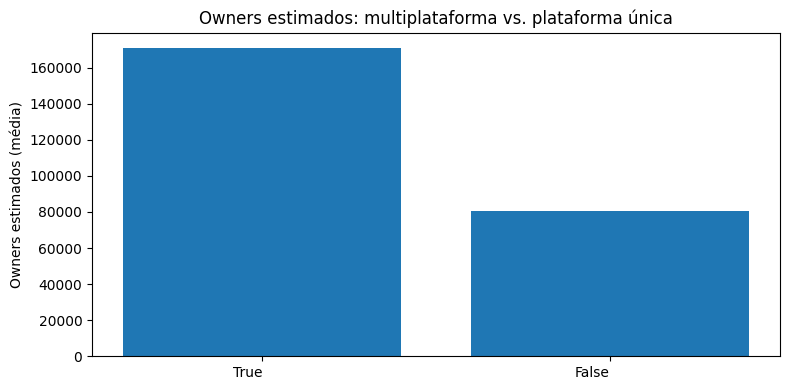

In [0]:
# Gráfico de barras dos owners estimados: multiplataforma vs. plataforma única.
bar_chart(q4.toPandas(), "is_multiplatform", "owners_medio", "Owners estimados: multiplataforma vs. plataforma única", "Owners estimados (média)", rotation=0)

**Discussão:** jogos multiplataforma (pelo menos duas entre Windows, Mac e Linux) têm aceitação média maior (79,7% vs. 74,3%) e **mais que o dobro** de owners estimados (170.715 vs. 80.406). **A resposta é sim**, e é a relação mais consistente entre popularidade e um atributo do jogo (fora DLCs, pergunta 6) encontrada nesta análise. Uma leitura possível: suportar múltiplas plataformas exige investimento de desenvolvimento maior, o que correlaciona com produções mais robustas — o suporte multiplataforma pode ser um proxy de orçamento/qualidade de produção, não necessariamente a causa direta do sucesso.

## Pergunta 5 — Tempo desde o lançamento impacta no volume acumulado de reviews?

In [0]:
# Pergunta 5: junta dim_game e fact_game por app_id, divide years_since_release (idade do jogo na data de
# coleta do dataset) em faixas de idade e calcula a média de review_count por faixa.
age_buckets = [
    ("<1 ano", lambda c: c < 1),
    ("1-3 anos", lambda c: (c >= 1) & (c < 3)),
    ("3-5 anos", lambda c: (c >= 3) & (c < 5)),
    ("5-10 anos", lambda c: (c >= 5) & (c < 10)),
    ("10+ anos", lambda c: c >= 10),
]
label, order = bucketize(F.col("years_since_release"), age_buckets)

q5 = (
    dim_game
    .join(fact_game, "app_id")
    .withColumn("idade_bucket", label)
    .withColumn("bucket_order", order)
    .groupBy("idade_bucket", "bucket_order")
    .agg(F.count("*").alias("n_jogos"), F.avg("review_count").alias("review_count_medio"))
    .orderBy("bucket_order")
    .drop("bucket_order")
)
display(q5)

idade_bucket,n_jogos,review_count_medio
<1 ano,18849,676.8573991627351
1-3 anos,23357,898.326709752098
3-5 anos,17030,1490.6837575082047
5-10 anos,27316,2095.4557639746904
10+ anos,3177,10523.300094667087


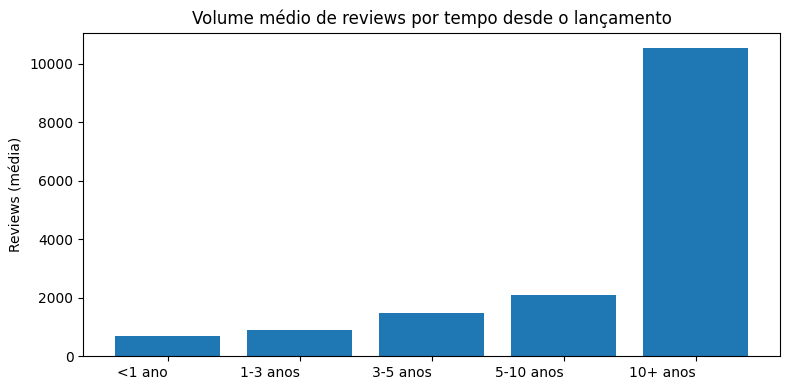

In [0]:
# Gráfico de barras do volume médio de reviews por faixa de tempo desde o lançamento.
bar_chart(q5.toPandas(), "idade_bucket", "review_count_medio", "Volume médio de reviews por tempo desde o lançamento", "Reviews (média)", rotation=0)

**Discussão:** a idade de cada jogo é medida até a data de coleta do dataset (2025-03-10), o mesmo momento em que as contagens de reviews foram registradas. O volume médio de reviews cresce de forma consistente com a idade do jogo — de 677 reviews (menos de 1 ano) para 10.523 (10+ anos), cerca de 15x mais, subindo em todas as faixas intermediárias (898, 1.491 e 2.095). **A resposta é sim**, e é o resultado mais esperado desta análise: reviews se acumulam ao longo do tempo, então jogos mais antigos naturalmente têm mais tempo de exposição à base de jogadores. Parte da diferença na faixa 10+ também reflete sobrevivência: os jogos antigos que continuam listados na Steam tendem a ser os que tiveram sucesso. Isso é um alerta de qualidade para qualquer comparação de popularidade entre jogos de idades muito diferentes — `review_count` sozinho favorece jogos antigos, não necessariamente jogos "melhores".

## Pergunta 6 — Jogos com mais DLCs tendem a ter maior popularidade (efeito "franquia")?

In [0]:
# Pergunta 6: divide dlc_count em faixas (0, 1-5, 6-20, 20+), agrupa por faixa e calcula a média de owners
# estimados.
dlc_buckets = [
    ("0", lambda c: c == 0),
    ("1-5", lambda c: (c >= 1) & (c <= 5)),
    ("6-20", lambda c: (c >= 6) & (c <= 20)),
    ("20+", lambda c: c > 20),
]
label, order = bucketize(F.col("dlc_count"), dlc_buckets)

q6 = (
    fact_game
    .withColumn("dlc_bucket", label)
    .withColumn("bucket_order", order)
    .groupBy("dlc_bucket", "bucket_order")
    .agg(F.count("*").alias("n_jogos"), F.avg("estimated_owners_avg").alias("owners_medio"))
    .orderBy("bucket_order")
    .drop("bucket_order")
)
display(q6)

dlc_bucket,n_jogos,owners_medio
0,75476,50178.00360379458
1-5,13001,277324.0519960003
6-20,970,1078432.9896907217
20+,282,2286542.5531914895


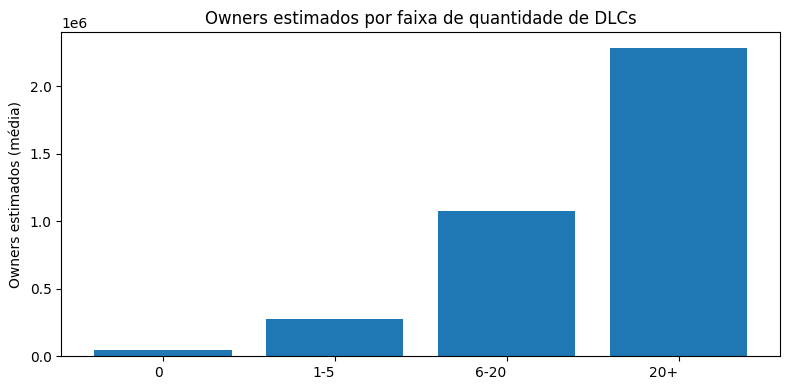

In [0]:
# Gráfico de barras dos owners estimados por faixa de quantidade de DLCs.
bar_chart(q6.toPandas(), "dlc_bucket", "owners_medio", "Owners estimados por faixa de quantidade de DLCs", "Owners estimados (média)", rotation=0)

**Discussão:** a relação é a mais forte de toda a análise. Jogos sem DLC têm em média 50.178 owners estimados; jogos com mais de 20 DLCs têm **2.286.542** — cerca de **45 vezes mais**. **A resposta é claramente sim**, confirmando o "efeito franquia": jogos que acumulam muitos DLCs ao longo do tempo são, quase por definição, os jogos mais populares e com maior ciclo de vida comercial (a editora só continua investindo em DLC para jogos que já venderam bem). Vale notar que a causalidade provavelmente corre nos dois sentidos: popularidade inicial leva a mais DLCs, e mais DLCs mantêm o jogo relevante por mais tempo.

## Pergunta 7 — Faixa etária exigida se relaciona com gênero, avaliação ou popularidade?

In [0]:
# Pergunta 7 (parte a): junta dim_game e fact_game por app_id, agrupa por has_age_restriction e calcula a média
# de acceptance_ratio e de owners estimados.
q7a = (
    dim_game
    .join(fact_game, "app_id")
    # has_age_restriction é NULL para o único jogo com required_age inválido na fonte
    # (tratado como nulo na Silver) — "desconhecido > 0" é desconhecido, não false.
    # Excluído desta comparação por não sabermos sua faixa etária real, não por erro.
    .filter(F.col("has_age_restriction").isNotNull())
    .groupBy("has_age_restriction")
    .agg(
        F.count("*").alias("n_jogos"),
        F.avg("acceptance_ratio").alias("acceptance_medio"),
        F.avg("estimated_owners_avg").alias("owners_medio"),
    )
)
display(q7a)

has_age_restriction,n_jogos,acceptance_medio,owners_medio
true,1056,73.86977428797891,1486851.3257575757
false,88672,75.60029411623168,84733.45588235294


In [0]:
# Pergunta 7 (parte b): entre os jogos com restrição de idade, conta quantos pertencem a cada gênero (junta a
# ponte com dim_genre e dim_game) e mostra os 10 gêneros mais frequentes.
q7b = (
    bridge_game_genre
    .join(dim_genre, "genre_id")
    .join(dim_game.filter("has_age_restriction = true"), "app_id")
    .groupBy("genre_name")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)
display(q7b)

genre_name,count
Action,695
Adventure,535
Indie,344
RPG,295
Casual,147
Strategy,143
Simulation,103
Free To Play,51
Early Access,49
Massively Multiplayer,36


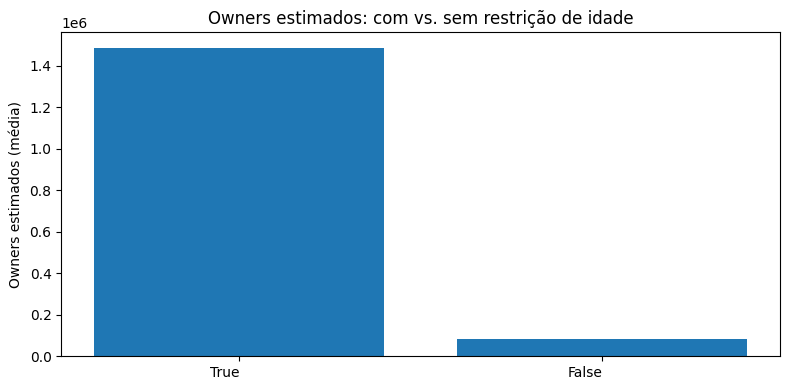

In [0]:
# Gráfico de barras dos owners estimados: com vs. sem restrição de idade.
bar_chart(q7a.toPandas(), "has_age_restriction", "owners_medio", "Owners estimados: com vs. sem restrição de idade", "Owners estimados (média)", rotation=0)

**Discussão:** o único jogo com `required_age` inválido na fonte (tratado como nulo na Etapa 5) fica com `has_age_restriction` nulo — "desconhecido maior que zero" é desconhecido, não `false` — e foi excluído desta comparação por não sabermos sua faixa etária real. Dos 89.728 jogos restantes, apenas **1.056 (1,2%)** declaram `required_age > 0` — a ressalva de amostra pequena da Etapa 1 se confirma. Dentro dessa amostra pequena, a aceitação média é ligeiramente **menor** (73,9% vs. 75,6%), mas o `estimated_owners` médio é cerca de **17,5 vezes maior** (1.486.851 vs. 84.733). Os gêneros mais comuns entre os jogos com restrição de idade são Action, Adventure, Indie e RPG — coerente com jogos de conteúdo mais maduro. A leitura mais provável não é "restrição de idade causa popularidade". Com uma amostra tão pequena, a média de owners é muito sensível a poucos títulos de grande sucesso — a popularidade na Steam é extremamente concentrada (ver outliers de `peak_ccu`/reviews no notebook 02), e bastam alguns jogos de grande porte com classificação indicativa declarada para multiplicar a média do grupo. Por isso a diferença deve ser lida como uma associação influenciada pela composição da amostra, não como um efeito da faixa etária em si.

## Pergunta 8 (stretch) — Nota da crítica está alinhada com a avaliação dos usuários?

In [0]:
# Pergunta 8: usa só os jogos com metacritic_score e acceptance_ratio disponíveis, calcula a correlação entre os
# dois e a média de acceptance_ratio por faixa de nota do Metacritic.
metacritic_buckets = [
    ("<=50", lambda c: c <= 50),
    ("51-70", lambda c: (c > 50) & (c <= 70)),
    ("71-80", lambda c: (c > 70) & (c <= 80)),
    ("81-90", lambda c: (c > 80) & (c <= 90)),
    ("91-100", lambda c: c > 90),
]
label, order = bucketize(F.col("metacritic_score"), metacritic_buckets)

base_q8 = fact_game.filter(F.col("metacritic_score").isNotNull() & F.col("acceptance_ratio").isNotNull())
print("Jogos com metacritic_score e acceptance_ratio disponíveis:", base_q8.count())

correlacao_metacritic = base_q8.select(F.corr("metacritic_score", "acceptance_ratio")).collect()[0][0]
print("Correlação metacritic_score x acceptance_ratio:", round(correlacao_metacritic, 4))

q8 = (
    base_q8
    .withColumn("metacritic_bucket", label)
    .withColumn("bucket_order", order)
    .groupBy("metacritic_bucket", "bucket_order")
    .agg(F.count("*").alias("n_jogos"), F.avg("acceptance_ratio").alias("acceptance_medio"))
    .orderBy("bucket_order")
    .drop("bucket_order")
)
display(q8)

Jogos com metacritic_score e acceptance_ratio disponíveis: 3574
Correlação metacritic_score x acceptance_ratio: 0.597


metacritic_bucket,n_jogos,acceptance_medio
<=50,114,54.73688493425034
51-70,1072,72.51616125340772
71-80,1491,82.69132351145737
81-90,842,89.00009881224084
91-100,55,90.98746598071557


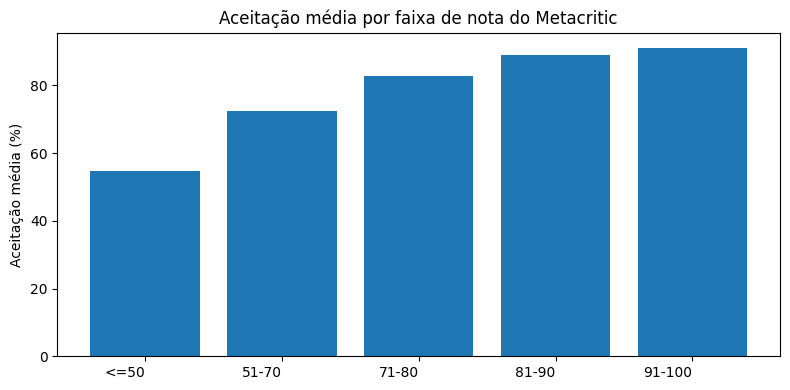

In [0]:
# Gráfico de barras da aceitação média por faixa de nota do Metacritic.
bar_chart(q8.toPandas(), "metacritic_bucket", "acceptance_medio", "Aceitação média por faixa de nota do Metacritic", "Aceitação média (%)", rotation=0)

**Discussão:** só 3.574 jogos (4,0%) têm `metacritic_score` e `acceptance_ratio` disponíveis ao mesmo tempo, confirmando a ressalva de baixa completude da Etapa 1. Dentro desse subconjunto, a correlação com `acceptance_ratio` é **0,60** (moderada a forte) e a tendência por faixa é monotônica: jogos com nota ≤50 têm aceitação média de 54,7%, subindo para 91,0% na faixa 91-100. **A resposta é sim, quando a nota existe**: crítica especializada e avaliação dos jogadores tendem a apontar na mesma direção, embora com dispersão suficiente para não serem intercambiáveis (correlação de 0,60 é moderada, não perfeita).

## Discussão geral

Voltando ao problema original — quais fatores mais se relacionam com aceitação e popularidade de um jogo na Steam:

- **Fatores associados à popularidade** (`estimated_owners`, `peak_ccu`): a quantidade de DLCs é o fator mais forte encontrado (cerca de 45x de diferença), seguido pelo suporte multiplataforma (2x) e, de forma mais fraca e possivelmente bidirecional, desconto ativo (+23%). A faixa etária mostrou uma diferença grande (17,5x), mas provavelmente reflete a composição de uma amostra pequena (poucos jogos declaram idade mínima, e a média é sensível a poucos títulos de grande sucesso) mais do que um efeito real da faixa etária.
- **Fatores associados à aceitação** (`acceptance_ratio`): a nota da crítica especializada é o sinal mais forte (correlação 0,60), mas só existe para 4% dos jogos. Gênero tem efeito modesto, com destaque para jogos Massively Multiplayer performando consistentemente pior. Suporte multiplataforma também favorece aceitação. **Preço não mostrou relação nenhuma com aceitação** — um achado que contraria a intuição de que jogos mais caros seriam mais bem avaliados.
- Volume de reviews cresce com o tempo, como esperado, o que reforça que comparações de popularidade entre jogos de idades muito diferentes precisam normalizar por tempo de mercado.

Todas as 8 perguntas do objetivo (Etapa 1) foram respondidas com os dados disponíveis; nenhuma foi descartada.